# TikTok Verified Status Prediction

## Logistic Regression Analysis

**Project:** TikTok data analysis  
**Objective:** Build and evaluate a logistic regression model to predict whether a TikTok account is **verified** based on video-level characteristics.

This notebook presents the exploratory analysis, feature preparation, model development, and evaluation.

## Executive Summary

This analysis investigates which video characteristics are associated with verified account status and uses logistic regression to predict the target. Exploratory analysis identified strong correlations among several engagement variables, so highly correlated features were considered when selecting the final predictors.

The original model achieved approximately **65% accuracy** on the held-out test set. Model performance differed substantially between the two classes, highlighting the importance of examining precision, recall, and the confusion matrix rather than relying on accuracy alone.

> **Methodology note:** The original analysis balanced the minority class before the train/test split. Because upsampling can duplicate observations, this can introduce data leakage if the same duplicated records appear in both sets. The existing results are therefore retained as part of the project history, but the metrics should be re-run after moving resampling to the training set only before using them as final portfolio metrics.

## 1. Setup and Data Loading

In [1]:
# Import packages for data loading, visualization, preprocessing, modeling, and evaluation.
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import resample

print('Python version: ', platform.python_version())

Python version:  3.13.7


In [2]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

## 2. Exploratory Data Analysis

In [3]:
# Display first few rows
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [4]:
# Get number of rows and columns
data.shape

(19382, 12)

In [5]:
# Get data types of columns
data.dtypes

#                             int64
claim_status                    str
video_id                      int64
video_duration_sec            int64
video_transcription_text        str
verified_status                 str
author_ban_status               str
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

In [6]:
# Get basic information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  str    
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  str    
 5   verified_status           19382 non-null  str    
 6   author_ban_status         19382 non-null  str    
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), str(4)
memory usage: 1.8 MB


In [7]:
# Generate basic descriptive stats
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [8]:
# Check for missing values
data.isnull().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [9]:
# Drop rows with missing values
data = data.dropna(axis=0)

In [10]:
# Display first few rows after handling missing values
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [11]:
# Check for duplicates

data.duplicated().sum()

np.int64(0)

### Outlier Review

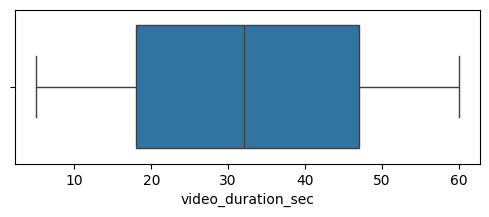

In [12]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(6, 2))
sns.boxplot(data= data, x= 'video_duration_sec')

plt.savefig("images/video_duration_boxplot.png", bbox_inches="tight")
plt.show()

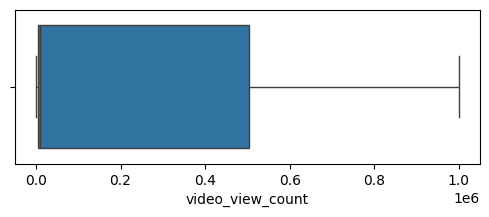

In [13]:
# Create a boxplot to visualize distribution of `video_view_count`

plt.figure(figsize=(6, 2))
sns.boxplot(data= data, x= 'video_view_count')

plt.savefig("images/video_view_boxplot.png", bbox_inches="tight")
plt.show()

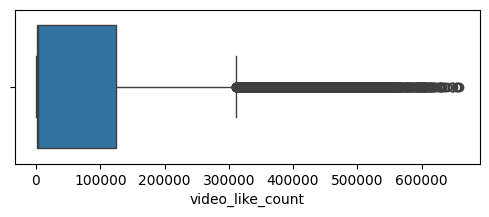

In [14]:
# Create a boxplot to visualize distribution of `video_like_count`

plt.figure(figsize=(6, 2))
sns.boxplot(data= data, x= 'video_like_count')

plt.savefig("images/video_likes_boxplot.png", bbox_inches="tight")
plt.show()

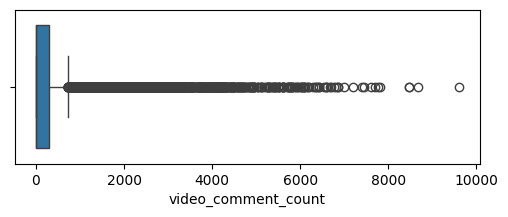

In [15]:
# Create a boxplot to visualize distribution of `video_comment_count`

plt.figure(figsize=(6, 2))
sns.boxplot(data= data, x= 'video_comment_count')

plt.savefig("images/video_comments_boxplot.png", bbox_inches="tight")
plt.show()

In [16]:
# Check for and handle outliers for video_like_count


Q1 = data['video_like_count'].quantile(0.25)
Q3 = data['video_like_count'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Check how many outliers there are
outliers = data[
    (data['video_like_count'] < lower_bound) |
    (data['video_like_count'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 1726


## 3. Class Balance

The target variable is highly imbalanced, with verified accounts representing a small minority of observations.

We first inspect the original class distribution. The train/test split and upsampling are performed later so that the test set remains untouched.


In [17]:
# Check class balance

data['verified_status'].value_counts(normalize=True) * 100

verified_status
not verified    93.71201
verified         6.28799
Name: proportion, dtype: float64

## 4. Correlation Analysis and Feature Selection

Before building the model, review correlations among the numerical engagement variables. Highly correlated predictors can make logistic regression coefficients harder to interpret.

Based on the correlation analysis, `video_like_count` is excluded from the final model to reduce redundancy among engagement variables.


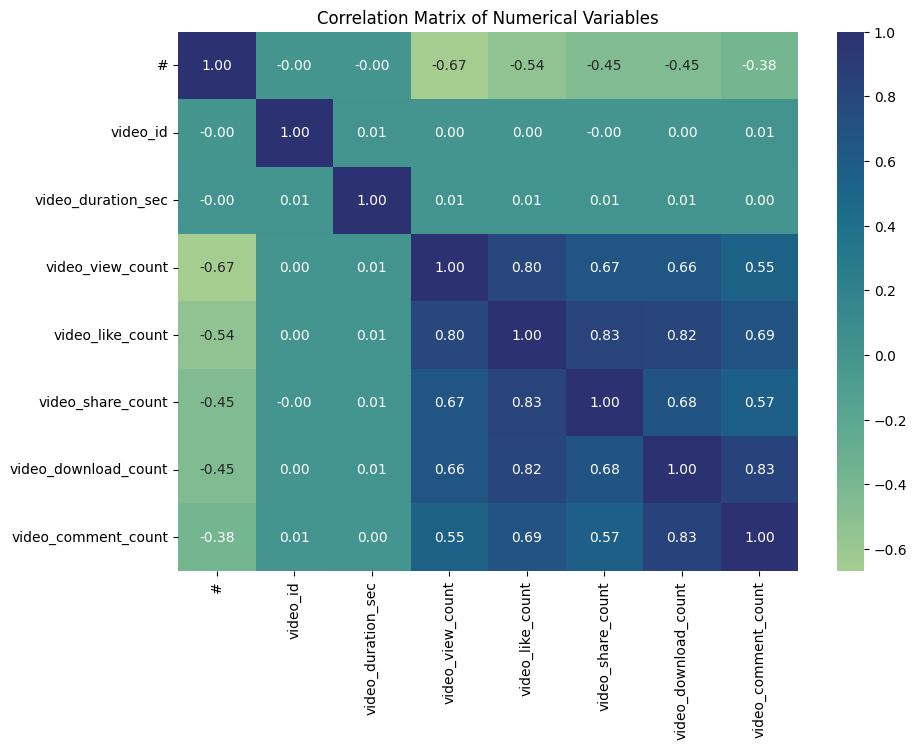

In [18]:
# Create a correlation matrix using numerical variables only.
numeric_data = data.select_dtypes(include="number")

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap="crest")
plt.title("Correlation Matrix of Numerical Variables")

plt.savefig("images/correlation_heatmap.png", bbox_inches="tight")
plt.show()


### Correlation Findings

The engagement variables show strong positive relationships with one another, particularly views, likes, shares, downloads, and comments. Because highly correlated predictors can create multicollinearity concerns in logistic regression, `video_like_count` is excluded from the final feature set.


## 5. Train/Test Split and Class Balancing

**Important:** The data is split **before** upsampling. Only the training data is balanced.

This prevents duplicated observations from appearing in both the training and testing sets and keeps the test set representative of the original data.


In [19]:
# Define the target and feature data.
X = data.drop("verified_status", axis=1)
y = data["verified_status"]

# Split first so the test set remains completely untouched.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (14313, 11)
Test set: (4771, 11)


In [20]:
# Combine the training features and target so only the training data can be resampled.
train_data = X_train.copy()
train_data["verified_status"] = y_train.values

# Separate the majority and minority classes in the training set.
verified_train = train_data[train_data["verified_status"] == "verified"]
unverified_train = train_data[train_data["verified_status"] == "not verified"]

print("Before upsampling:")
print(train_data["verified_status"].value_counts())


Before upsampling:
verified_status
not verified    13413
verified          900
Name: count, dtype: int64


In [21]:
# Upsample the verified class using training data only.
verified_upsampled = resample(
    verified_train,
    replace=True,
    n_samples=len(unverified_train),
    random_state=42
)

# Combine both classes and shuffle the balanced training data.
train_balanced = pd.concat(
    [unverified_train, verified_upsampled]
).sample(frac=1, random_state=42).reset_index(drop=True)

print("After upsampling:")
print(train_balanced["verified_status"].value_counts())


After upsampling:
verified_status
verified        13413
not verified    13413
Name: count, dtype: int64


In [22]:
# Separate the balanced training data back into features and target.
X_train_balanced = train_balanced.drop("verified_status", axis=1)
y_train_balanced = train_balanced["verified_status"]


## 6. Feature Preparation

The model does not need the video ID or free-text transcription. The categorical variables are one-hot encoded.

The test set is encoded using the same training-derived columns so that no information from the test set is used to train the model.


In [23]:
# Remove identifiers, free-text data, and the highly correlated like-count feature.
drop_cols = [
    "video_id",
    "video_transcription_text",
    "video_like_count"
]

X_train_clean = X_train_balanced.drop(
    columns=[c for c in drop_cols if c in X_train_balanced.columns]
)

X_test_clean = X_test.drop(
    columns=[c for c in drop_cols if c in X_test.columns]
)

# One-hot encode categorical variables.
X_train_encoded = pd.get_dummies(X_train_clean, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_clean, drop_first=True)

# Make sure the test set has exactly the same columns as the training set.
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Training features:", X_train_encoded.shape)
print("Testing features:", X_test_encoded.shape)


Training features: (26826, 9)
Testing features: (4771, 9)


## 7. Train the Logistic Regression Model


In [24]:
# Train logistic regression on the balanced training data.
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_encoded,
    y_train_balanced
)


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

## 8. Model Evaluation

The model is evaluated on the **original, untouched test set**. Accuracy is reported together with precision, recall, F1-score, ROC-AUC, and a confusion matrix because the original target is imbalanced.


In [25]:
# Generate predictions and predicted probabilities for the untouched test set.
y_pred = log_reg.predict(X_test_encoded)
y_pred_proba = log_reg.predict_proba(X_test_encoded)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="verified"))
print("Recall:", recall_score(y_test, y_pred, pos_label="verified"))
print("F1:", f1_score(y_test, y_pred, pos_label="verified"))
print(
    "ROC-AUC:",
    roc_auc_score((y_test == "verified").astype(int), y_pred_proba)
)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.5288199538880738
Precision: 0.09851607584501236
Recall: 0.7966666666666666
F1: 0.17534849596478358
ROC-AUC: 0.6705211362111384

Classification Report:
              precision    recall  f1-score   support

not verified       0.97      0.51      0.67      4471
    verified       0.10      0.80      0.18       300

    accuracy                           0.53      4771
   macro avg       0.54      0.65      0.42      4771
weighted avg       0.92      0.53      0.64      4771



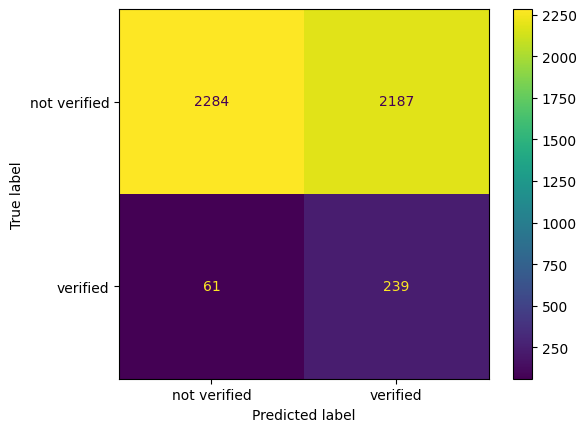

In [26]:
# Display the confusion matrix for the untouched test set.
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["not verified", "verified"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["not verified", "verified"]
)

disp.plot()
plt.show()


## 9. Model Coefficients


In [27]:
# Review the model coefficients.
# Positive coefficients increase the estimated log-odds of verified status;
# negative coefficients decrease the estimated log-odds.
coefficient_df = pd.DataFrame({
    "Feature": log_reg.feature_names_in_,
    "Coefficient": log_reg.coef_[0],
    "Odds Ratio": np.exp(log_reg.coef_[0])
}).sort_values("Coefficient", ascending=False)

coefficient_df


,Feature,Coefficient,Odds Ratio
6,claim_status_opinion,1.895237e+00,6.654125
5,video_comment_count,3.975319e-04,1.000398
3,video_share_count,4.446449e-06,1.000004
2,video_view_count,-1.157088e-07,1.000000
0,#,-1.489521e-05,0.999985
4,video_download_count,-1.521887e-04,0.999848
1,video_duration_sec,-7.533250e-04,0.999247
8,author_ban_status_under review,-1.573226e-01,0.854428
7,author_ban_status_banned,-5.169133e-01,0.596358


## 10. Conclusions and Recommendations

### Key Findings

- The target variable is strongly imbalanced, with verified accounts representing a small minority of the original dataset.
- Several engagement variables are strongly correlated, so `video_like_count` was excluded from the final model to reduce redundancy.
- The model was trained after splitting the data, with upsampling applied **only to the training set**.
- Model performance should be interpreted using precision, recall, F1-score, ROC-AUC, and the confusion matrix rather than accuracy alone.
- The model coefficients describe associations with verified status; they do not establish causation.

### Recommendations

1. Use the corrected train/test workflow for the final reported model results.
2. Compare logistic regression with other classification models.
3. Evaluate future models using the same untouched test set.
4. Investigate the strongest predictors further to understand which video characteristics are associated with verified status.


## 11. Next Steps

- Re-run the notebook from the beginning after confirming the dataset path.
- Record the revised model metrics from the corrected workflow.
- Update the portfolio README with the revised results.
- Keep the original test set untouched throughout model development.
